In [25]:
cd '/kaggle/input'

/kaggle/input


In [26]:
!apt-get update && apt-get install -y tree

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease               
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease     
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease                 
Hit:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease               
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease                     
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease   
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.

In [27]:
cd '/kaggle/input/datasets/nagahuy/tdtt-ver2'

/kaggle/input/datasets/nagahuy/tdtt-ver2


In [28]:
!tree -L 1

.
├── images
├── metadata
└── noises

3 directories, 0 files


In [29]:
import os
import json
from collections import defaultdict
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

ROOT = '/kaggle/input/datasets/nagahuy/tdtt-ver2'

IMAGES_DIR = os.path.join(ROOT, "images")
METADATA_DIR = os.path.join(ROOT, "metadata")
NOISE_DIR = os.path.join(ROOT, "noises")

In [30]:
# for root, dirs, files in os.walk(ROOT):
#     level = root.replace(ROOT, '').count(os.sep)
#     indent = ' ' * 2 * level
#     print(f"{indent}{os.path.basename(root)}/")
    
#     subindent = ' ' * 2 * (level + 1)
#     for f in files[:5]:  # limit file preview
#         print(f"{subindent}{f}")

# 1) Visualize an image with specified path

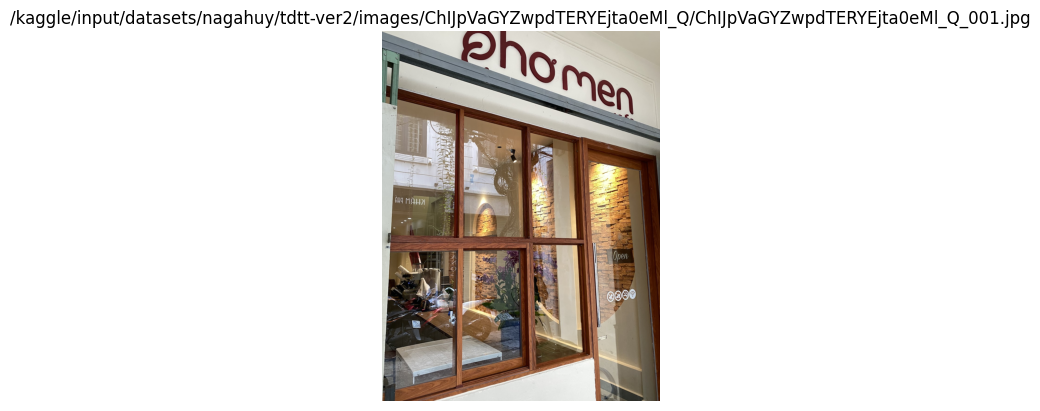

In [31]:
def show_image(img_path):
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(img_path)
    plt.show()

# Example: pick first image from first place
place_ids = os.listdir(IMAGES_DIR)
sample_place = place_ids[0]

sample_images = os.listdir(os.path.join(IMAGES_DIR, sample_place))
sample_img_path = os.path.join(IMAGES_DIR, sample_place, sample_images[0])

show_image(sample_img_path)

In [32]:
total_images = 0

for place_id in os.listdir(IMAGES_DIR):
    place_path = os.path.join(IMAGES_DIR, place_id)
    if os.path.isdir(place_path):
        total_images += len(os.listdir(place_path))

print("Total images:", total_images)

Total images: 21389


In [33]:
place_image_counts = {}

for place_id in os.listdir(IMAGES_DIR):
    place_path = os.path.join(IMAGES_DIR, place_id)
    if os.path.isdir(place_path):
        place_image_counts[place_id] = len(os.listdir(place_path))

df_counts = pd.DataFrame(list(place_image_counts.items()), columns=["place_id", "num_images"])
df_counts.sort_values("num_images", ascending=False).head()

,place_id,num_images
657,ChIJ245VTQwvdTERoJjl87LXYCw,15
779,ChIJ40c6dzQvdTERFXwVwcYrhGI,15
1420,ChIJyx8_wRwndTERRWGeFd1cwt0,15
449,ChIJm4AG804vdTEROb9iGC1EnAs,15
1617,ChIJO5FZBkIvdTER0RBWzFc-6NQ,15


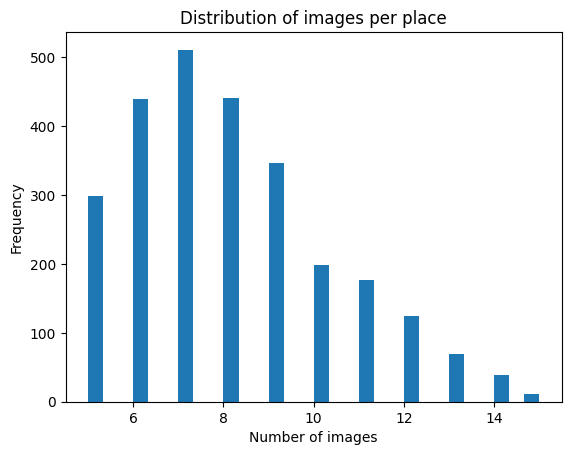

In [34]:
plt.hist(df_counts["num_images"], bins=30)
plt.title("Distribution of images per place")
plt.xlabel("Number of images")
plt.ylabel("Frequency")
plt.show()

In [35]:
image_sizes = []

for place_id in tqdm(os.listdir(IMAGES_DIR)):
    place_path = os.path.join(IMAGES_DIR, place_id)
    
    if not os.path.isdir(place_path):
        continue
        
    for img_name in os.listdir(place_path):
        img_path = os.path.join(place_path, img_name)
        
        try:
            img = Image.open(img_path)
            image_sizes.append(img.size)  # (width, height)
        except:
            continue

df_sizes = pd.DataFrame(image_sizes, columns=["width", "height"])
df_sizes.head()

100%|██████████| 2655/2655 [00:59<00:00, 44.82it/s]


,width,height
0,1200,1600
1,1200,1600
2,1200,1600
3,1600,901
4,1600,900


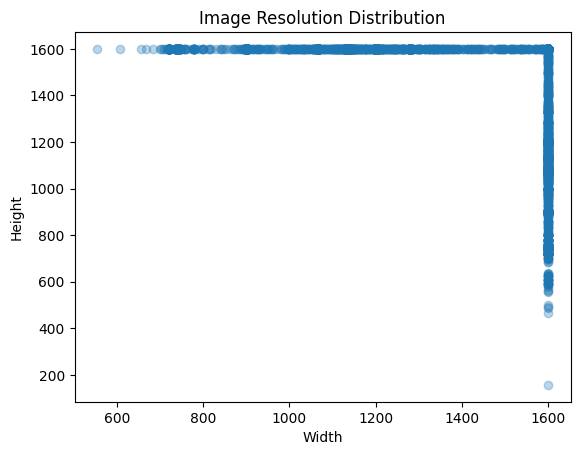

In [36]:
plt.scatter(df_sizes["width"], df_sizes["height"], alpha=0.3)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Resolution Distribution")
plt.show()

In [37]:
noise_stats = {}

for category in os.listdir(NOISE_DIR):
    cat_path = os.path.join(NOISE_DIR, category)
    
    if os.path.isdir(cat_path):
        noise_stats[category] = len(os.listdir(cat_path))

pd.DataFrame(list(noise_stats.items()), columns=["category", "count"])

,category,count
0,bill,10
1,text,17
2,food,14


In [38]:
def load_json(filename):
    path = os.path.join(METADATA_DIR, filename)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

places = load_json("places.json")
clean_reviews = load_json("clean_reviews.json")
raw_reviews = load_json("raw_reviews.json")
images_metadata = load_json("images_metadata.json")

print("Places:", len(places))
print("Clean reviews:", len(clean_reviews))
print("Raw reviews:", len(raw_reviews))
print("Images metadata:", len(images_metadata))

Places: 2655
Clean reviews: 159050
Raw reviews: 159300
Images metadata: 21389


In [39]:
df_places = pd.DataFrame(places)
df_reviews = pd.DataFrame(clean_reviews)
df_images_meta = pd.DataFrame(images_metadata)

df_places.head()

,place_id,name,type,address,district,city,lat,lng,avg_rating,total_reviews,source
0,ChIJ98T7azsvdTERrUAWQAIRWTo,"""C+ Cafe"" Cafe and More",food,"230 Nguyễn Thị Minh Khai, Xuân Hòa, Hồ Chí Min...",Xuân Hòa,Hồ Chí Minh,10.774407,106.689876,4.4,202,google_maps
1,ChIJY41T6kYvdTERS92294dJ1J4,% Arabica,food,"42 Nguyễn Huệ, Street, Sài Gòn, Hồ Chí Minh ...","Street, Sài Gòn",Hồ Chí Minh,10.774086,106.704106,4.2,4006,google_maps
2,ChIJMdBTSBEpdTERu_OLRdqqPfw,+Little Cam Saigon (Nguyễn Văn Trỗi),food,"42/1 Đ. Nguyễn Văn Trỗi, Cầu Kiệu, Hồ Chí Minh...",Cầu Kiệu,Hồ Chí Minh,10.793978,106.678988,4.6,141,google_maps
3,ChIJI_H0_qwvdTERJyeQ65ctFKU,.,food,"634 Lạc Long Quân, Tân Hòa, Hồ Chí Minh 72115,...",Tân Hòa,Hồ Chí Minh,10.774999,106.648517,5.0,114,google_maps
4,ChIJGWb9ZespdTER3HlZ8ICzCdM,0.coffee&bar,food,"375/9 Hoàng Sa, Tân Định, Hồ Chí Minh 70000, V...",Tân Định,Hồ Chí Minh,10.793082,106.687029,4.9,109,google_maps


In [40]:
# Check place_id consistency giữa images và metadata
image_place_ids = set(os.listdir(IMAGES_DIR))
metadata_place_ids = set(df_places["place_id"])

print("Missing in metadata:", image_place_ids - metadata_place_ids)
print("Missing in images:", metadata_place_ids - image_place_ids)

Missing in metadata: set()
Missing in images: set()


In [41]:
df_images_meta.sample(5)

,image_id,place_id,file_path,tags
12575,image_ec14336c0ce40256d6e096a782233d72,ChIJaW-KVvcudTERPQNq-A0a5bk,images/ChIJaW-KVvcudTERPQNq-A0a5bk/ChIJaW-KVvc...,[]
11085,image_528f97f14ba7801d2150df0d90a1d109,ChIJWduRFsMpdTERxxE8nLxiRhM,images/ChIJWduRFsMpdTERxxE8nLxiRhM/ChIJWduRFsM...,[]
3801,image_e02737487e416e755c88460eb60727df,ChIJBU0ZbT4vdTERlrvIUkwHySs,images/ChIJBU0ZbT4vdTERlrvIUkwHySs/ChIJBU0ZbT4...,[]
15118,image_9de2ed41a3bd8e78596ad1f7826f17e2,ChIJhXfbe0LXdDERlDv0g-F_moc,images/ChIJhXfbe0LXdDERlDv0g-F_moc/ChIJhXfbe0L...,[]
2335,image_e4df6da5c9d493295b9293a165ab3b84,ChIJ6YlxvdEvdTER_9NYLyA-oRQ,images/ChIJ6YlxvdEvdTER_9NYLyA-oRQ/ChIJ6YlxvdE...,[]


In [42]:
print("Avg images per place:", df_counts["num_images"].mean())
print("Min images:", df_counts["num_images"].min())
print("Max images:", df_counts["num_images"].max())

Avg images per place: 8.056120527306968
Min images: 5
Max images: 15


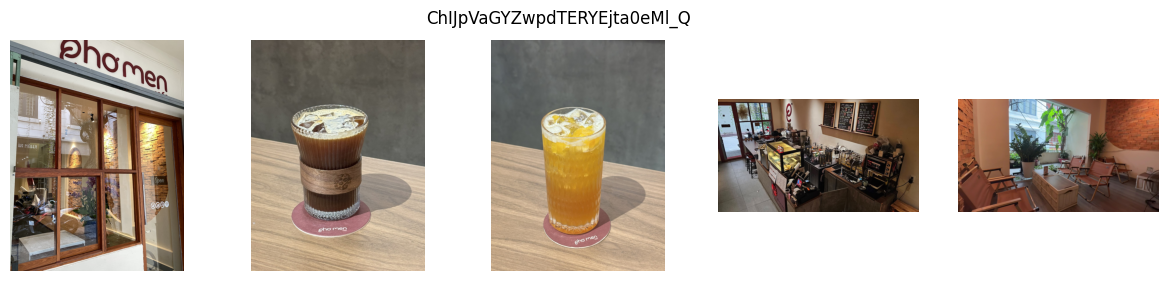

In [43]:
def show_place_images(place_id, n=5):
    place_path = os.path.join(IMAGES_DIR, place_id)
    imgs = os.listdir(place_path)[:n]
    
    plt.figure(figsize=(15, 3))
    
    for i, img_name in enumerate(imgs):
        img_path = os.path.join(place_path, img_name)
        img = Image.open(img_path)
        
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")
    
    plt.suptitle(place_id)
    plt.show()

show_place_images(sample_place)

# CLIP pipeline (on full data)

## Cell 1: Set up + imports

In [1]:
import os
import json
import numpy as np
import torch

from PIL import Image
from tqdm import tqdm

from transformers import CLIPProcessor, CLIPModel

ROOT = "/kaggle/input/datasets/nagahuy/tdtt-ver2"

IMAGES_DIR = os.path.join(ROOT, "images")
NOISE_DIR = os.path.join(ROOT, "noises")
METADATA_DIR = os.path.join(ROOT, "metadata")

SAVE_DIR = "/kaggle/working/embeddings"
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)

DEVICE: cuda


## Cell 2: Load metadata

In [55]:
def load_json(name):
    with open(os.path.join(METADATA_DIR, name), "r", encoding="utf-8") as f:
        return json.load(f)

places = load_json("places.json")

place_map = {
    p["place_id"]: p
    for p in places
}

print("Loaded places:", len(place_map))

Loaded places: 2655


## Cell 3: Load CLIP model

In [60]:
MODEL_NAME = "laion/CLIP-ViT-H-14-laion2B-s32B-b79K"

processor = CLIPProcessor.from_pretrained(MODEL_NAME)
model = CLIPModel.from_pretrained(MODEL_NAME)

model.to(DEVICE)
model.eval()

print("Loaded:", MODEL_NAME)
print(type(model))

Loading weights:   0%|          | 0/910 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: laion/CLIP-ViT-H-14-laion2B-s32B-b79K
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: laion/CLIP-ViT-H-14-laion2B-s32B-b79K
<class 'transformers.models.clip.modeling_clip.CLIPModel'>


## Cell 4: Embedding Functions

In [61]:
def normalize_embeddings(x):
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    return x / norms


def embed_images_batch(image_paths):

    images = []
    valid_paths = []

    for p in image_paths:

        try:
            img = Image.open(p).convert("RGB")

            # keep aspect ratio
            img.thumbnail((768, 768))

            images.append(img)
            valid_paths.append(p)

        except Exception as e:
            print(f"ERROR reading {p}: {e}")

    if len(images) == 0:
        return np.array([]), []

    inputs = processor(
        images=images,
        return_tensors="pt",
        padding=True
    ).to(DEVICE)

    with torch.no_grad():
    
        outputs = model.vision_model(
            pixel_values=inputs["pixel_values"]
        )
    
        pooled = outputs.pooler_output
    
        embeddings = model.visual_projection(pooled)
    
    embeddings = embeddings.cpu().numpy()

    embeddings = normalize_embeddings(embeddings)

    return embeddings, valid_paths

## Cell 5: Encode Noise Embeddings

In [62]:
noise_embeddings = []
noise_index = []

BATCH_SIZE = 64

print("=" * 60)
print("ENCODING NOISE IMAGES")
print("=" * 60)

for category in os.listdir(NOISE_DIR):

    category_path = os.path.join(NOISE_DIR, category)

    if not os.path.isdir(category_path):
        continue

    image_paths = [
        os.path.join(category_path, f)
        for f in os.listdir(category_path)
    ]

    print(f"\nCategory: {category}")
    print(f"Images  : {len(image_paths)}")

    for i in tqdm(range(0, len(image_paths), BATCH_SIZE)):

        batch = image_paths[i:i+BATCH_SIZE]

        emb_batch, valid_paths = embed_images_batch(batch)

        for j, path in enumerate(valid_paths):

            idx = len(noise_embeddings)

            noise_embeddings.append(emb_batch[j])

            noise_index.append({
                "idx": idx,
                "category": category,
                "file_path": path
            })

noise_embeddings = np.array(noise_embeddings)

np.save(
    os.path.join(SAVE_DIR, "noise_embeddings.npy"),
    noise_embeddings
)

with open(
    os.path.join(SAVE_DIR, "noise_index.json"),
    "w"
) as f:
    json.dump(noise_index, f, indent=2)

print("\nDone")
print("Noise embeddings shape:", noise_embeddings.shape)

ENCODING NOISE IMAGES

Category: bill
Images  : 10


100%|██████████| 1/1 [00:01<00:00,  1.32s/it]



Category: text
Images  : 17


100%|██████████| 1/1 [00:02<00:00,  2.56s/it]



Category: food
Images  : 14


100%|██████████| 1/1 [00:02<00:00,  2.21s/it]


Done
Noise embeddings shape: (41, 1024)


## Cell 6: Encode Place Images + Filter Noises

In [63]:
NOISE_THRESHOLD = 0.73

image_embeddings = []
image_index = []

print("=" * 60)
print("ENCODING PLACE IMAGES")
print("=" * 60)

for place_id in tqdm(os.listdir(IMAGES_DIR)):

    place_path = os.path.join(IMAGES_DIR, place_id)

    if not os.path.isdir(place_path):
        continue

    image_paths = [
        os.path.join(place_path, f)
        for f in os.listdir(place_path)
    ]

    for i in range(0, len(image_paths), BATCH_SIZE):

        batch = image_paths[i:i+BATCH_SIZE]

        emb_batch, valid_paths = embed_images_batch(batch)

        for j, path in enumerate(valid_paths):

            emb = emb_batch[j]

            sims = emb @ noise_embeddings.T

            max_noise_sim = sims.max()
            noise_idx = sims.argmax()

            if max_noise_sim > NOISE_THRESHOLD:

                print(
                    f"[FILTERED] "
                    f"{os.path.basename(path)} | "
                    f"noise={noise_index[noise_idx]['category']} | "
                    f"score={max_noise_sim:.4f}"
                )

                continue

            idx = len(image_embeddings)

            image_embeddings.append(emb)

            image_index.append({
                "idx": idx,
                "place_id": place_id,
                "image_id": os.path.basename(path),
                "file_path": path
            })

image_embeddings = np.array(image_embeddings)

np.save(
    os.path.join(SAVE_DIR, "image_embeddings.npy"),
    image_embeddings
)

with open(
    os.path.join(SAVE_DIR, "image_index.json"),
    "w"
) as f:
    json.dump(image_index, f, indent=2)

print("\nDone")
print("Image embeddings shape:", image_embeddings.shape)

ENCODING PLACE IMAGES


  0%|          | 1/2655 [00:01<1:02:38,  1.42s/it]

[FILTERED] ChIJpVaGYZwpdTERYEjta0eMl_Q_008.jpg | noise=food | score=0.7000
[FILTERED] ChIJpVaGYZwpdTERYEjta0eMl_Q_005.jpg | noise=food | score=0.6834
[FILTERED] ChIJpVaGYZwpdTERYEjta0eMl_Q_006.jpg | noise=food | score=0.5936
[FILTERED] ChIJpVaGYZwpdTERYEjta0eMl_Q_003.jpg | noise=food | score=0.5804
[FILTERED] ChIJpVaGYZwpdTERYEjta0eMl_Q_010.jpg | noise=food | score=0.7523
[FILTERED] ChIJpVaGYZwpdTERYEjta0eMl_Q_009.jpg | noise=food | score=0.6404
[FILTERED] ChIJpVaGYZwpdTERYEjta0eMl_Q_002.jpg | noise=food | score=0.7033
[FILTERED] ChIJpVaGYZwpdTERYEjta0eMl_Q_007.jpg | noise=food | score=0.7418


  0%|          | 2/2655 [00:03<1:11:34,  1.62s/it]

[FILTERED] ChIJjTxnTJ8vdTER7miSZ_zmeX4_002.jpg | noise=food | score=0.6031
[FILTERED] ChIJjTxnTJ8vdTER7miSZ_zmeX4_013.jpg | noise=food | score=0.7086
[FILTERED] ChIJjTxnTJ8vdTER7miSZ_zmeX4_012.jpg | noise=food | score=0.6894
[FILTERED] ChIJjTxnTJ8vdTER7miSZ_zmeX4_007.jpg | noise=food | score=0.6429
[FILTERED] ChIJjTxnTJ8vdTER7miSZ_zmeX4_004.jpg | noise=text | score=0.5783
[FILTERED] ChIJjTxnTJ8vdTER7miSZ_zmeX4_010.jpg | noise=food | score=0.7204
[FILTERED] ChIJjTxnTJ8vdTER7miSZ_zmeX4_003.jpg | noise=text | score=0.5802
[FILTERED] ChIJjTxnTJ8vdTER7miSZ_zmeX4_005.jpg | noise=food | score=0.5568
[FILTERED] ChIJjTxnTJ8vdTER7miSZ_zmeX4_006.jpg | noise=food | score=0.6384


...

[FILTERED] ChIJm-gZAiUvdTERF1P6ptacTwc_003.jpg | noise=food | score=0.7289
[FILTERED] ChIJm-gZAiUvdTERF1P6ptacTwc_010.jpg | noise=food | score=0.6848
[FILTERED] ChIJm-gZAiUvdTERF1P6ptacTwc_004.png | noise=text | score=0.5875
[FILTERED] ChIJm-gZAiUvdTERF1P6ptacTwc_006.jpg | noise=food | score=0.6051
[FILTERED] ChIJm-gZAiUvdTERF1P6ptacTwc_008.jpg | noise=food | score=0.6703
[FILTERED] ChIJm-gZAiUvdTERF1P6ptacTwc_009.jpg | noise=food | score=0.7438


100%|█████████▉| 2654/2655 [59:53<00:01,  1.22s/it]

[FILTERED] ChIJrWqAAwAndTERfeF6gD0qXeM_004.jpg | noise=text | score=0.6702
[FILTERED] ChIJrWqAAwAndTERfeF6gD0qXeM_005.jpg | noise=food | score=0.5663
[FILTERED] ChIJrWqAAwAndTERfeF6gD0qXeM_002.jpg | noise=food | score=0.6266


100%|██████████| 2655/2655 [59:54<00:00,  1.35s/it]

[FILTERED] ChIJyceqWiIvdTERSDUjiuaqHpE_005.jpg | noise=food | score=0.5904
[FILTERED] ChIJyceqWiIvdTERSDUjiuaqHpE_006.jpg | noise=food | score=0.5734
[FILTERED] ChIJyceqWiIvdTERSDUjiuaqHpE_002.jpg | noise=food | score=0.6206

Done
Image embeddings shape: (5729, 1024)


## Cell 7: Load Embeddings

In [64]:
image_embeddings = np.load(
    os.path.join(SAVE_DIR, "image_embeddings.npy")
)

noise_embeddings = np.load(
    os.path.join(SAVE_DIR, "noise_embeddings.npy")
)

with open(
    os.path.join(SAVE_DIR, "image_index.json")
) as f:
    image_index = json.load(f)

with open(
    os.path.join(SAVE_DIR, "noise_index.json")
) as f:
    noise_index = json.load(f)

def embed_single_image_path(path):

    emb, _ = embed_images_batch([path])

    return emb[0]

print("Loaded image embeddings:", image_embeddings.shape)
print("Loaded noise embeddings:", noise_embeddings.shape)

Loaded image embeddings: (5729, 1024)
Loaded noise embeddings: (41, 1024)


## Cell 8: Retrieval Config

In [65]:
PLACE_THRESHOLD = 0.65

TOP_K = 3

TOP_IMAGES_PER_PLACE = 3

TOP_IMAGE_CANDIDATES = 50

## Cell 9: Main Retrieval Logic

In [67]:
def aggregate_place_score(scores):

    scores = sorted(scores, reverse=True)

    max_score = scores[0]

    top3_mean = np.mean(scores[:3])

    final_score = (
        0.7 * max_score +
        0.3 * top3_mean
    )

    return float(final_score)


def search_image(image_path):

    try:
        query_emb = embed_single_image_path(image_path)

    except Exception as e:

        return {
            "status": "error",
            "message": str(e)
        }

    # =========================================================
    # NOISE CHECK
    # =========================================================

    noise_sims = query_emb @ noise_embeddings.T

    max_noise_sim = noise_sims.max()

    best_noise_idx = noise_sims.argmax()

    if max_noise_sim > NOISE_THRESHOLD:

        return {
            "status": "invalid",
            "reason": "similar_to_noise",
            "noise_category":
                noise_index[best_noise_idx]["category"],
            "noise_score":
                float(max_noise_sim),
            "noise_image":
                noise_index[best_noise_idx]["file_path"]
        }

    # =========================================================
    # IMAGE RETRIEVAL
    # =========================================================

    sims = query_emb @ image_embeddings.T

    top_indices = sims.argsort()[-TOP_IMAGE_CANDIDATES:][::-1]

    place_dict = defaultdict(list)

    for idx in top_indices:

        score = float(sims[idx])

        meta = image_index[idx]

        place_id = meta["place_id"]

        place_dict[place_id].append({
            "score": score,
            "image_id": meta["image_id"],
            "file_path": meta["file_path"]
        })

    # =========================================================
    # PLACE AGGREGATION
    # =========================================================

    results = []

    for place_id, images in place_dict.items():

        image_scores = [
            x["score"]
            for x in images
        ]

        place_score = aggregate_place_score(
            image_scores
        )

        if place_score < PLACE_THRESHOLD:
            continue

        images_sorted = sorted(
            images,
            key=lambda x: x["score"],
            reverse=True
        )

        results.append({
            "place_id": place_id,
            "score": place_score,
            "images": images_sorted[:TOP_IMAGES_PER_PLACE],
            "metadata": place_map.get(place_id, {})
        })

    results = sorted(
        results,
        key=lambda x: x["score"],
        reverse=True
    )[:TOP_K]

    if len(results) == 0:

        return {
            "status": "no_match"
        }

    return {
        "status": "ok",
        "results": results
    }

## Cell 10: Debug Retrieval

In [69]:
def debug_search_image(image_path):

    print("=" * 60)
    print("GENERATING EMBEDDING")
    print("=" * 60)

    query_emb = embed_single_image_path(image_path)

    print("Embedding shape:", query_emb.shape)

    # =========================================================
    # NOISE CHECK
    # =========================================================

    print("\n")
    print("=" * 60)
    print("NOISE CHECK")
    print("=" * 60)

    noise_sims = query_emb @ noise_embeddings.T

    best_noise_idx = noise_sims.argmax()

    print(
        "Best noise similarity:",
        float(noise_sims.max())
    )

    print(
        "Noise category:",
        noise_index[best_noise_idx]["category"]
    )

    print(
        "Noise image:",
        noise_index[best_noise_idx]["file_path"]
    )

    print(
        "Noise threshold:",
        NOISE_THRESHOLD
    )

    # =========================================================
    # IMAGE RETRIEVAL
    # =========================================================

    print("\n")
    print("=" * 60)
    print("RAW IMAGE RETRIEVAL")
    print("=" * 60)

    sims = query_emb @ image_embeddings.T

    top_indices = sims.argsort()[-10:][::-1]

    for rank, idx in enumerate(top_indices, start=1):

        meta = image_index[idx]

        print(
            f"[{rank}] "
            f"score={float(sims[idx]):.4f} | "
            f"place={meta['place_id']} | "
            f"image={meta['image_id']}"
        )

    # =========================================================
    # FINAL RESULTS
    # =========================================================

    print("\n")
    print("=" * 60)
    print("FINAL RESULTS")
    print("=" * 60)

    result = search_image(image_path)

    import pprint
    pprint.pprint(result)

    return result

## Cell 11: URL Retrieval

In [70]:
def search_image_from_url(url):

    response = requests.get(url)

    image = Image.open(
        requests.get(url, stream=True).raw
    ).convert("RGB")

    temp_path = "/kaggle/working/temp_query.jpg"

    image.save(temp_path)

    return search_image(temp_path)


def debug_search_image_from_url(url):

    image = Image.open(
        requests.get(url, stream=True).raw
    ).convert("RGB")

    temp_path = "/kaggle/working/temp_debug.jpg"

    image.save(temp_path)

    return debug_search_image(temp_path)

## Cell 12: Test URL

In [77]:
import requests
from io import BytesIO
from collections import defaultdict

url = "https://lh3.googleusercontent.com/gps-cs-s/APNQkAHAG_XbkvUE2Q0zj9ft2OzerS7-x-dVdvnqsP1-TlE2of5X7tb5JPRqsZzBz0_t0mtKMSwtEa2TTLMqhWtKKAKhFdFql5OgPWseV0zpU-2NDv3WvRmvpbl2ixX2W0B0XeAVGonBw8nWNlUK=s1360-w1360-h1020-rw"

result = debug_search_image_from_url(url)

result

GENERATING EMBEDDING
Embedding shape: (1024,)


NOISE CHECK
Best noise similarity: 0.5829724669456482
Noise category: food
Noise image: /kaggle/input/datasets/nagahuy/tdtt-ver2/noises/food/ChIJgRwlQ5MvdTERqQ_32WTjau8_005.jpg
Noise threshold: 0.55


RAW IMAGE RETRIEVAL
[1] score=0.6799 | place=ChIJqWLsWFgndTERt4a8GVzTPno | image=ChIJqWLsWFgndTERt4a8GVzTPno_007.jpg
[2] score=0.6644 | place=ChIJkR0JuwAvdTERNRfvA_LZSN4 | image=ChIJkR0JuwAvdTERNRfvA_LZSN4_005.jpg
[3] score=0.6613 | place=ChIJe-bsI4EtdTER5CWPb6ZdR0E | image=ChIJe-bsI4EtdTER5CWPb6ZdR0E_001.jpg
[4] score=0.6275 | place=ChIJd1uT6DcvdTERAq9bN05v4xk | image=ChIJd1uT6DcvdTERAq9bN05v4xk_006.jpg
[5] score=0.6220 | place=ChIJgZglzugudTERopa2fWkTO8A | image=ChIJgZglzugudTERopa2fWkTO8A_002.jpg
[6] score=0.6186 | place=ChIJOw0qHPEvdTERpVaZA1fO1Oc | image=ChIJOw0qHPEvdTERpVaZA1fO1Oc_003.jpg
[7] score=0.6185 | place=ChIJxfqegBzRdDER7K30G1w4E1s | image=ChIJxfqegBzRdDER7K30G1w4E1s_002.jpg
[8] score=0.6038 | place=ChIJAUlV8N8udTERmTMsSPLqsjs

{'status': 'invalid',
 'reason': 'similar_to_noise',
 'noise_category': 'food',
 'noise_score': 0.5829724669456482,
 'noise_image': '/kaggle/input/datasets/nagahuy/tdtt-ver2/noises/food/ChIJgRwlQ5MvdTERqQ_32WTjau8_005.jpg'}